# Visualización con Seaborn

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Pregunta 1:** Utilizando el conjunto de datos "Flights" graficar:

* Mediante un diagrama de barras, la media de pasajeros por año entre 1954 y 1960. 
* ¿ Cúal fue el año que en promedio hubo mayor afluencia de pasajeros ?

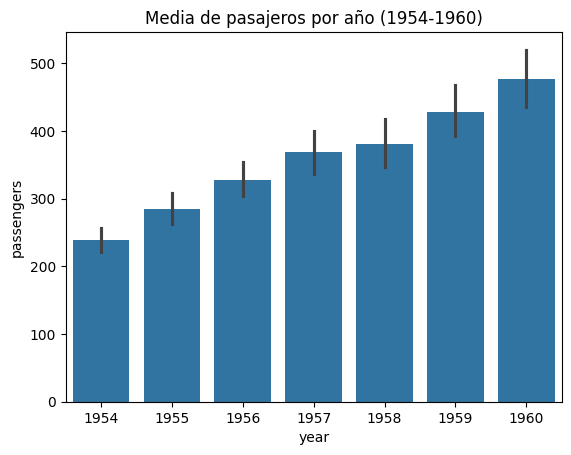

In [2]:
# Cargar dataset
flights = sns.load_dataset("flights")

# Filtrar años entre 1954 y 1960
flights_filtrado = flights[(flights["year"] >= 1954) & (flights["year"] <= 1960)]

# Graficar media de pasajeros por año
sns.barplot(data=flights_filtrado, x="year", y="passengers", estimator="mean")

plt.title("Media de pasajeros por año (1954-1960)")
plt.show()

El año con mayor media de pasajeros es: 1960

**Pregunta 2:** Utilizando el conjunto de datos "Flights" graficar:

* Mediante un diagrama de barras la suma de pasajeros por año entre 1954 y 1960. 
* ¿ Cúal fue el año en que hubo mayor afluencia de pasajeros ?

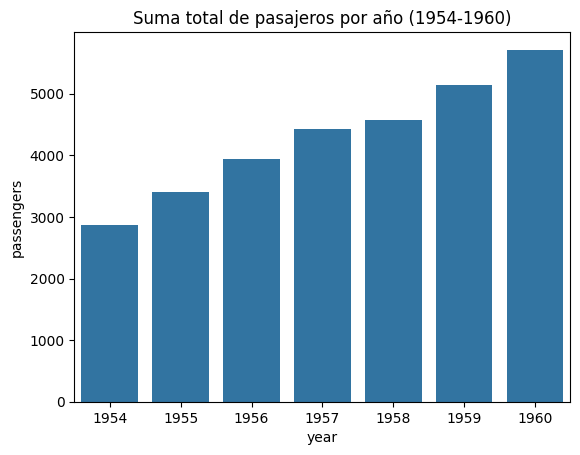

In [3]:
# Cargar dataset
flights = sns.load_dataset("flights")

# Filtrar años
flights_filtrado = flights[(flights["year"] >= 1954) & (flights["year"] <= 1960)]

# Graficar suma por año
sns.barplot(
    data=flights_filtrado,
    x="year",
    y="passengers",
    estimator=sum,
    errorbar=None
)

plt.title("Suma total de pasajeros por año (1954-1960)")
plt.show()

El año con mayor afluencia de pasajeros es: 1960

**Pregunta 3:** Utilizando el conjunto de datos "planets":

* Mediante un countplot mostrar cuantos registros se realizaron por cada método.
* Remarcar con un color diferente aquel que tenga mayor cantidad de registros.

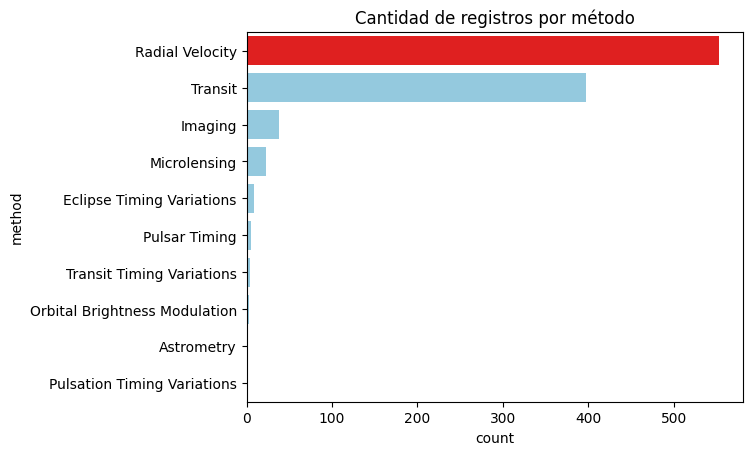

In [4]:
# Cargar dataset
planets = sns.load_dataset("planets")

# Obtener conteo por método
conteo = planets["method"].value_counts()

# Identificar el método con más registros
max_method = conteo.idxmax()

# Crear lista de colores (resaltar el mayor)
colors = [
    "red" if method == max_method else "skyblue"
    for method in conteo.index
]

# Graficar countplot
sns.countplot(
    data=planets,
    y="method",
    order=conteo.index,
    hue="method",
    palette=colors,
    legend=False)

plt.title("Cantidad de registros por método")
plt.show()

**Pregunta 4:** Utilizando el conjunto de datos "planets":

* Se desea saber en cuantos registros donde se utilizó el método "Radial Velocity" el valor de "mass" es valido e invalido(NaN).

In [5]:
# Cargar dataset
planets = sns.load_dataset("planets")

# Filtrar Radial Velocity
radial = planets[planets["method"] == "Radial Velocity"]

# Contar inválidos (NaN)
invalidos = radial["mass"].isna().sum()

# Contar válidos (no NaN)
validos = radial["mass"].notna().sum()

int(validos), int(invalidos)

(510, 43)

Para el método Radial Velocity, existen 510 registro con valor válido en la columna "mass" y 43 registros inválidos.

**Pregunta 5:** Utilizando el conjunto de datos "planets":

* Se desea visualizar mediante un swarmplot el periodo orbital por cada uno de los planetas.

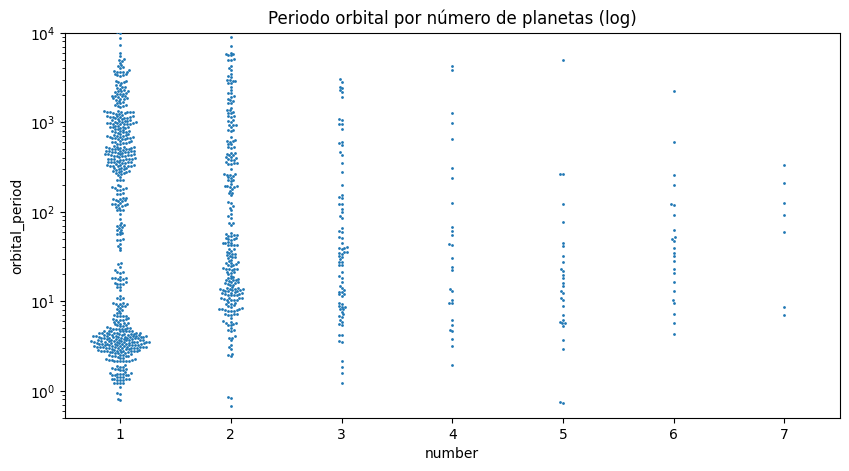

In [6]:
planets = sns.load_dataset("planets")

# Filtrar solo filas con orbital_period válido 
df = planets.dropna(subset=["orbital_period"])

# Crear figura/ejes y fijar límites ANTES de dibujar
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_yscale("log")
ax.set_ylim(0.5, 1e4)  

# Dibujar swarmplot
sns.swarmplot(
    data=df,
    x="number",
    y="orbital_period",
    size=2,             
    ax=ax
)

ax.set_title("Periodo orbital por número de planetas (log)")
plt.show()

**Pregunta 6:** Utilizando el conjunto de datos "planets":

* Se desea visualizar mediante un stripplot el periodo orbital por cada uno de los métodos y agruparlo por planeta.

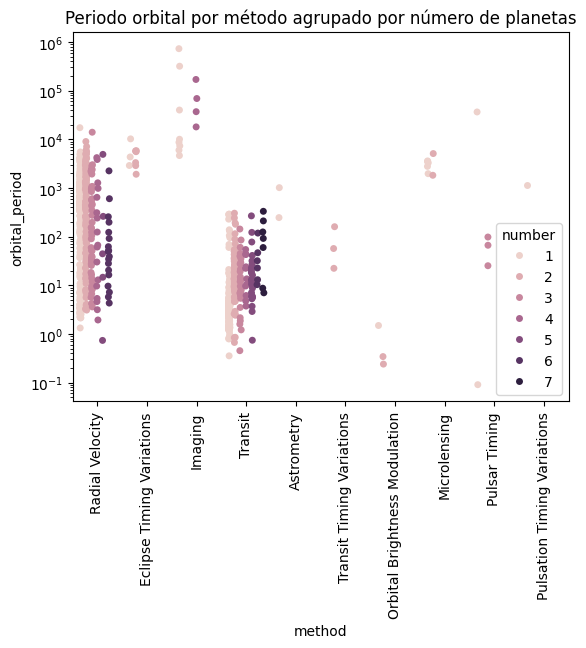

In [7]:
planets = sns.load_dataset("planets")

# eliminar valores nulos
planets = planets.dropna(subset=["orbital_period"])

sns.stripplot(
    x="method",
    y="orbital_period",
    hue="number",
    data=planets,
    jitter=True,
    dodge=True
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Periodo orbital por método agrupado por número de planetas")
plt.show()

**Pregunta 7:** Utilizando el conjunto de datos "mpg":

* Mediante un barplot se desea saber que vehiculos consumen más combustible en promedio según su procedencia.


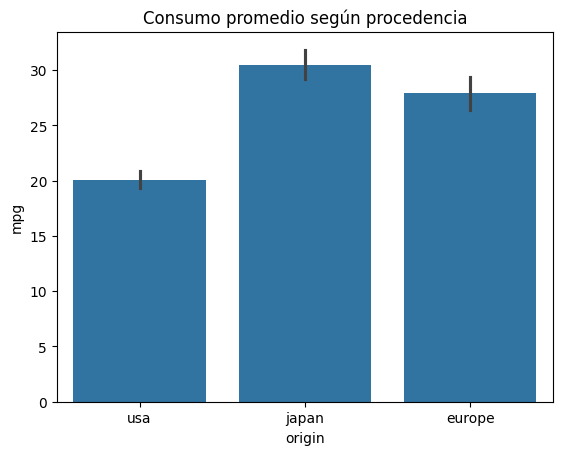

In [8]:
mpg = sns.load_dataset("mpg")

sns.barplot(
    x="origin",
    y="mpg",
    data=mpg
)

plt.title("Consumo promedio según procedencia")
plt.show()

Los vehiculos de procedencia USA son los que consumen más combustible en promedio, ya que presentan el menor valor de mpg.

**Pregunta 8:** Utilizando el conjunto de datos "mpg":

* ¿Qué tipo de correlación tiene la aceleración respecto al peso?

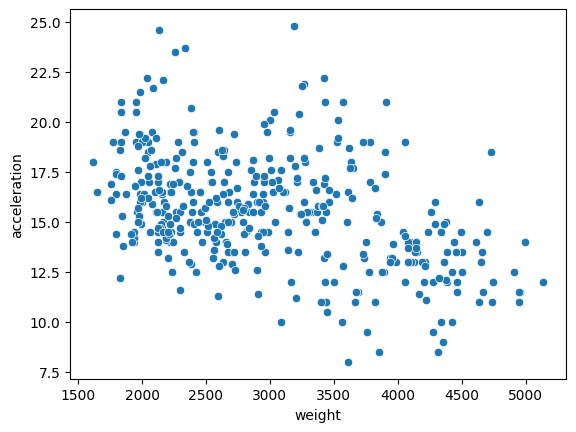

In [9]:
sns.scatterplot(x="weight", y="acceleration", data=mpg)
plt.show()

Es una correlación negativa, a medida que el peso aumenta, la aceleración disminuye

**Pregunta 9:** Utilizando el conjunto de datos "mpg":

* ¿La cantidad de cilindros influye en los caballos de potencia?
* Visualizarlo mediante un stripplot

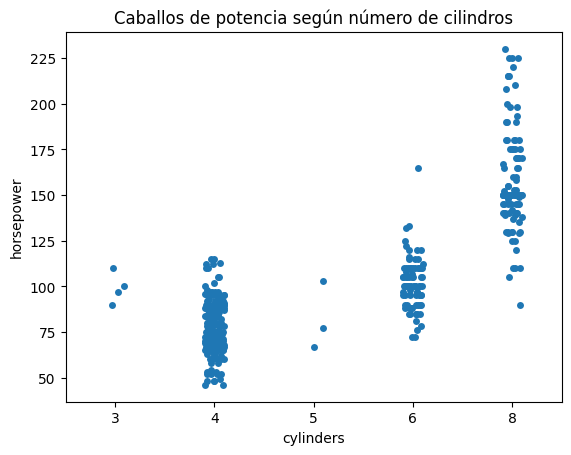

In [10]:
mpg = sns.load_dataset("mpg")

# eliminar valores nulos de horsepower
mpg = mpg.dropna(subset=["horsepower"])

sns.stripplot(
    x="cylinders",
    y="horsepower",
    data=mpg,
    jitter=True
)

plt.title("Caballos de potencia según número de cilindros")
plt.show()

Sí, la cantidad de cilindros influye en los caballos de potencia. A mayor número de cilindros, mayor potencia.

**Pregunta 10:** Utilizando el conjunto de datos "mpg":

* Graficar la distribución del consumo de gasolina "mpg"  por año de los vehiculos de procedencia japonesa mediante un boxplot.
* Configurar las marcas del eje "y" con los cuartiles para que coincidan con el boxplot.

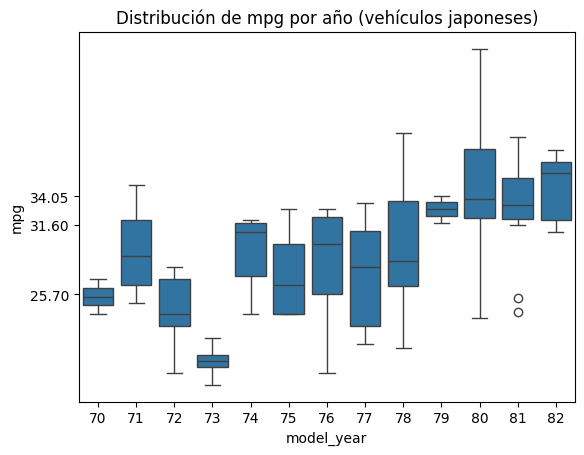

In [12]:
mpg = sns.load_dataset("mpg")

# Filtrar solo vehículos japoneses
mpg_japan = mpg[mpg["origin"] == "japan"]

# Crear boxplot
sns.boxplot(
    x="model_year",
    y="mpg",
    data=mpg_japan
)

# Calcular cuartiles globales
q1 = mpg_japan["mpg"].quantile(0.25)
q2 = mpg_japan["mpg"].quantile(0.50)
q3 = mpg_japan["mpg"].quantile(0.75)

# Configurar marcas del eje Y
plt.yticks([q1, q2, q3])

plt.title("Distribución de mpg por año (vehículos japoneses)")
plt.show()

**Pregunta 11:** Utilizando el conjunto de datos "mpg":

* Realizar un diagrama de pares.
* Analizar las correlaciones.

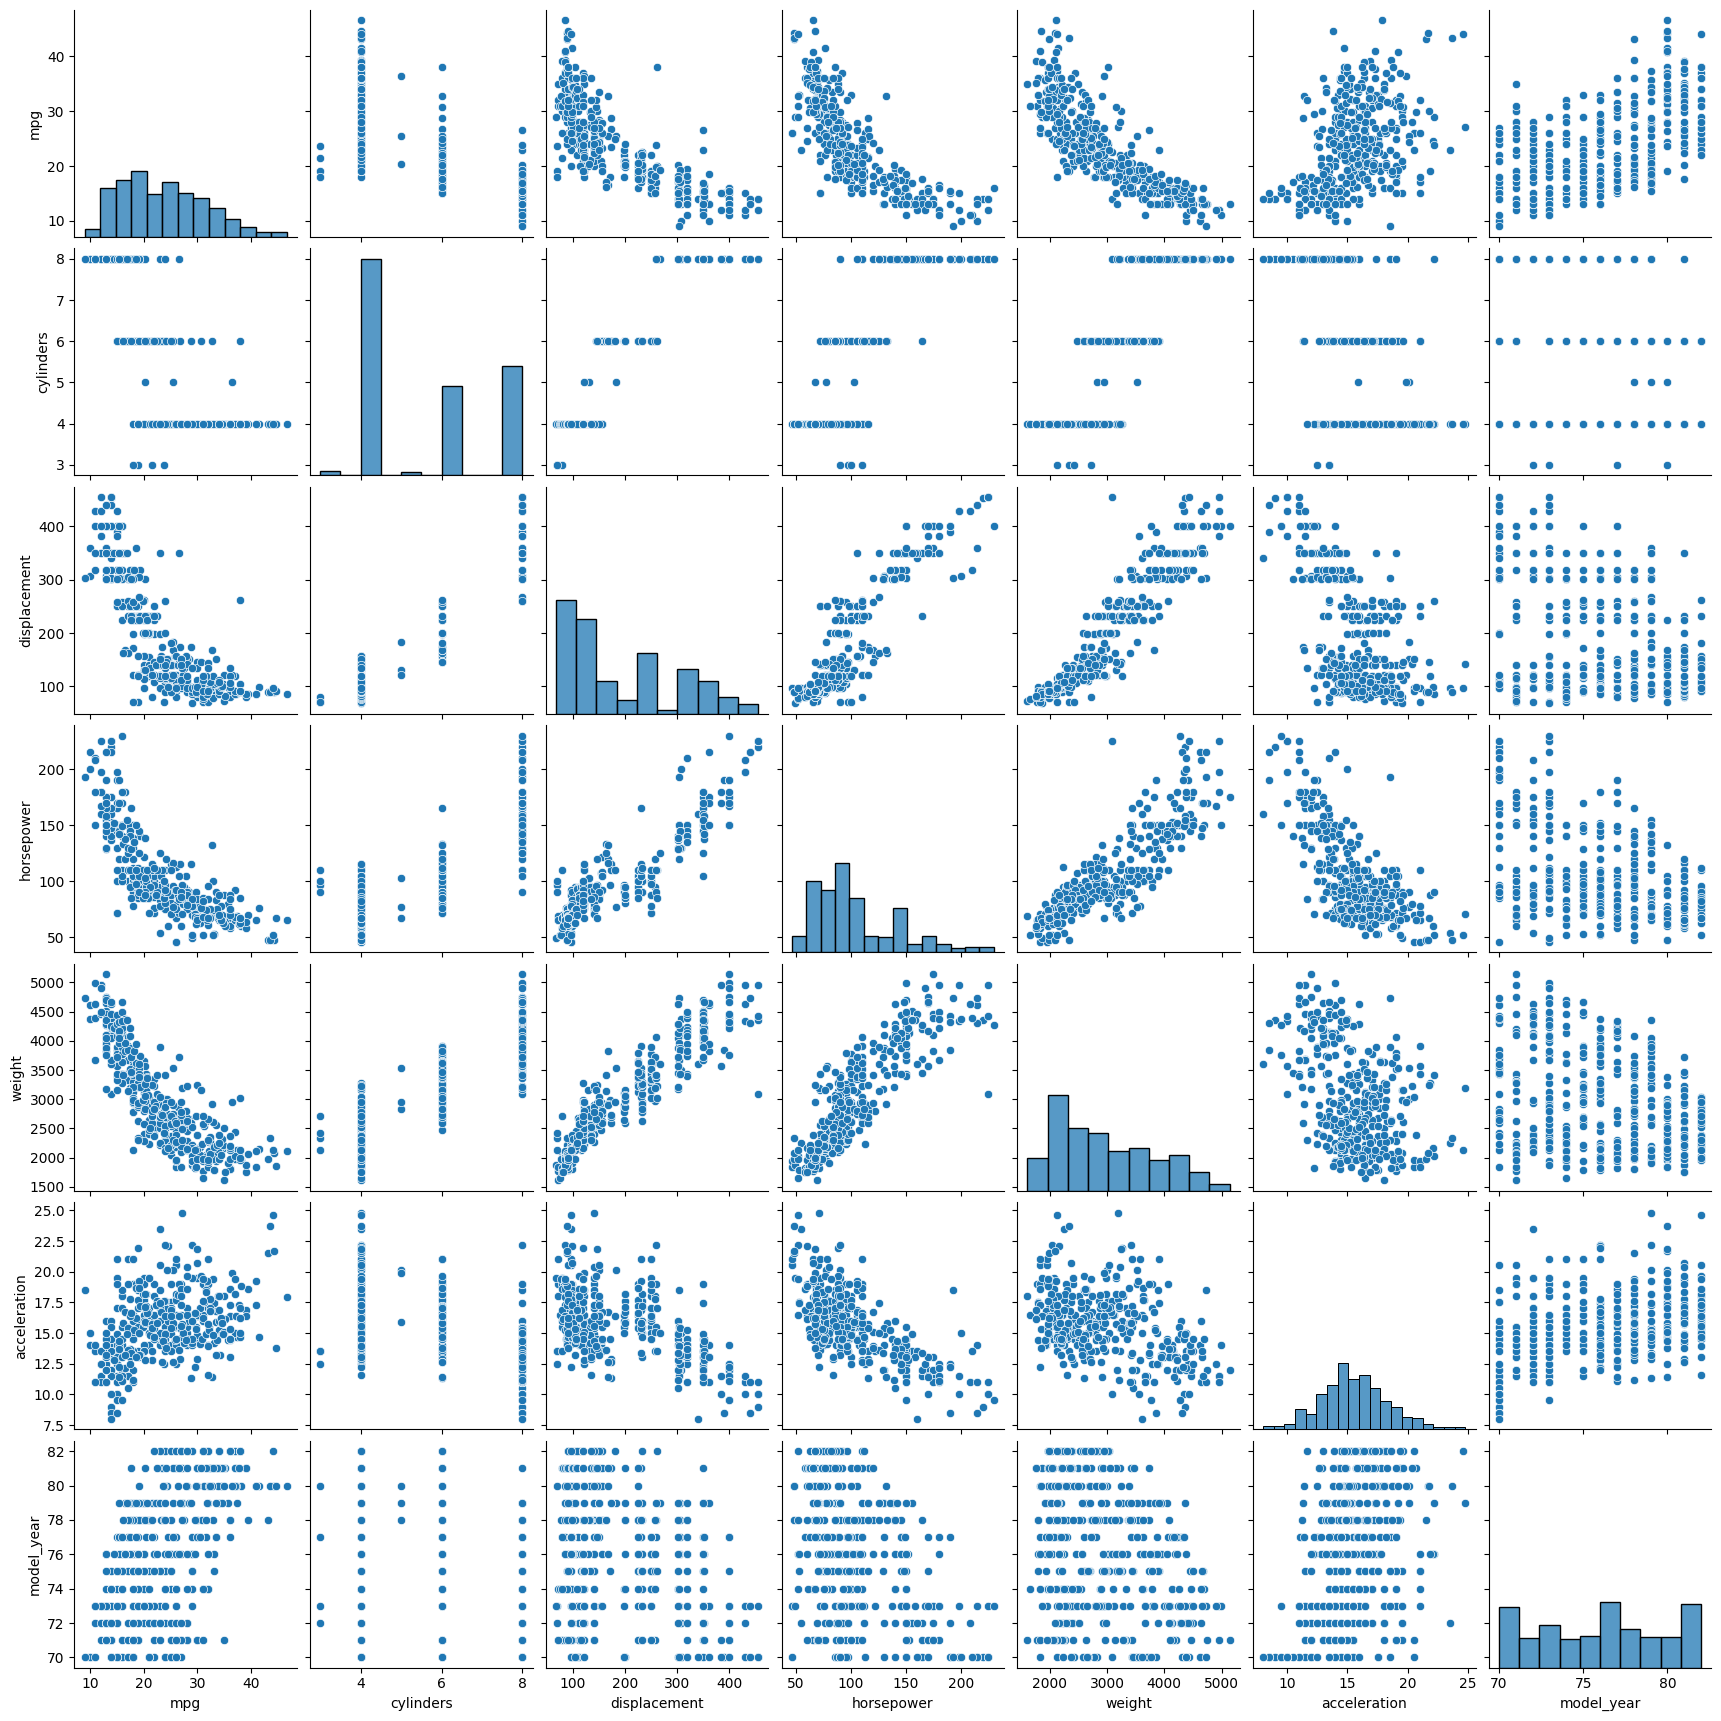

In [13]:
mpg = sns.load_dataset("mpg")

sns.pairplot(mpg)
plt.show()


El diagrama de pares muestra correlación negativa entre mpg y peso, cilindros y potencia. También existe correlación positiva entre peso, cilindros y caballos de potencia.

**Pregunta 12:** Utilizando el conjunto de datos "mpg":

* Calcular las correlaciones.
* Gráficar las correlaciones en un heatmap.

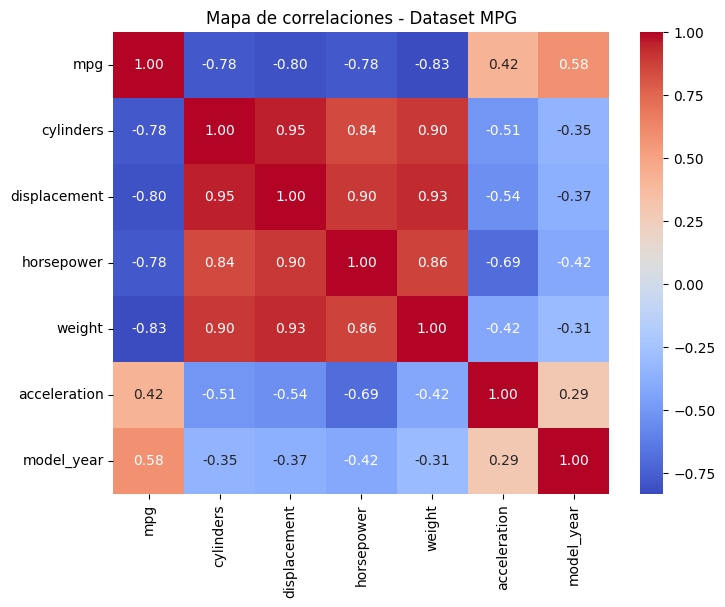

In [15]:
mpg = sns.load_dataset("mpg")

# Calcular correlaciones
corr = mpg.corr(numeric_only=True)

# Crear heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de correlaciones - Dataset MPG")
plt.show()

**Pregunta 13:** Utilizando el conjunto de datos "penguins":

* Crear 4 ejes.
* Gráficar el conteo por especies.
* Diagrama de dispersión de **bill_length_mm** con respecto a **bill_depth_mm**
* Diagrama de barras por sexo con el promedio **body_mass_g** 
* KDE de la especie **Chinstrap** respecto **body_mass_g**

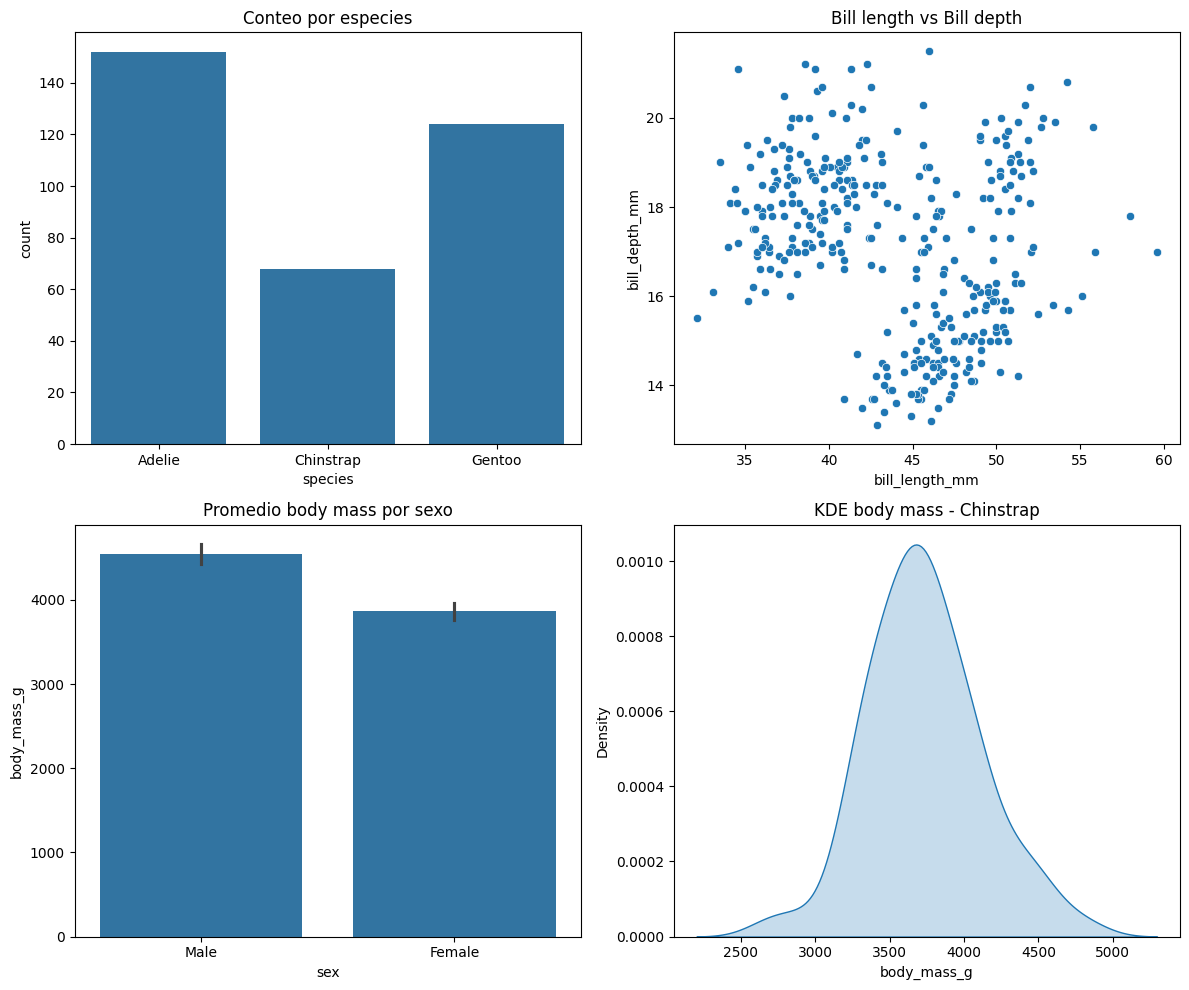

In [17]:
penguins = sns.load_dataset("penguins")

# Crear figura con 4 ejes 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Conteo por especies
sns.countplot(
    x="species",
    data=penguins,
    ax=axes[0,0]
)
axes[0,0].set_title("Conteo por especies")

# Scatter bill_length vs bill_depth
sns.scatterplot(
    x="bill_length_mm",
    y="bill_depth_mm",
    data=penguins,
    ax=axes[0,1]
)
axes[0,1].set_title("Bill length vs Bill depth")

# Barplot promedio body_mass por sexo
sns.barplot(
    x="sex",
    y="body_mass_g",
    data=penguins,
    ax=axes[1,0]
)
axes[1,0].set_title("Promedio body mass por sexo")

# KDE solo Chinstrap
chinstrap = penguins[penguins["species"] == "Chinstrap"]

sns.kdeplot(
    x="body_mass_g",
    data=chinstrap,
    fill=True,
    ax=axes[1,1]
)
axes[1,1].set_title("KDE body mass - Chinstrap")

plt.tight_layout()
plt.show()

**Pregunta 14:** Utilizando el conjunto de datos "penguins" replicar el siguiente gráfico.

<center><img width="400"  src="output.png" /> <center/>

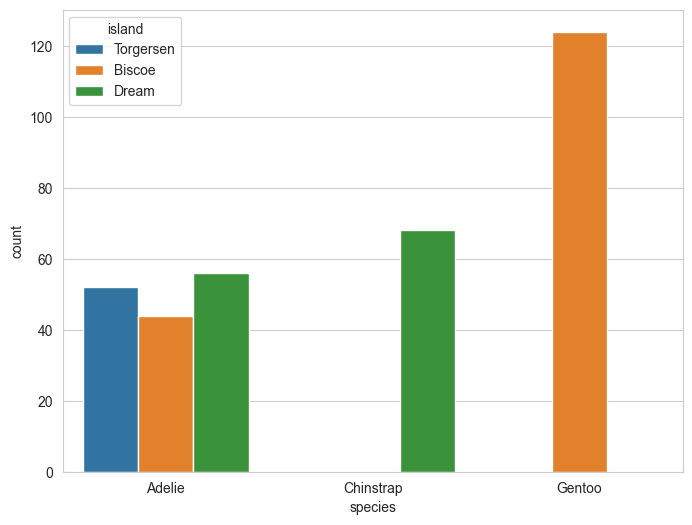

In [20]:
penguins = sns.load_dataset("penguins")

sns.set_style("whitegrid")

plt.figure(figsize=(8,6))

sns.countplot(
    x="species",
    hue="island",
    data=penguins
)

plt.xlabel("species")
plt.ylabel("count")

plt.show()